### Задание:
**Задача 1: EDA таблицы payments**

Изучите таблицу payments и проведите разведочный анализ данных. Для этого нужно ответить на вопросы
+ определите сколько в таблице строк  и столбцов
+ выведите среднее, медиану, минимум, максимум и стандартное отклонение для колонки sum_payment
+ выведите количество нуллов. Можем ли мы заполнить нуллы значениями
+ выведите количество выбросов. Очистите данные от выбросов
+ постройте график с распределением sum_payment (sns.histplot)

**Задача 2**
Агрегируйте данные по пользователю и месяцу

**Задача 3**
Рассчитайте выручку и количество тренировок в динамике по месяцам. Постройте графики

**Задача 4** 
Рассчитайте LT и LTR. Подумайте, должны ли мы учитывать при расчете все когорты пользователей

**Задача 5**
Оцените эффект от маркетинговой акции для выручки и для прибыли (при условии, что переменные косты на 1 занятие равны 800 руб. для индивидуальной тренировки и 200 руб. для групповой)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Загрузка данных из CSV - файла в переменную payments.
payments = pd.read_csv('payments.csv')
payments.head()

,id_user,training_type,sum_payment,date
0,1000,indiv,1800.0,2023-03-04
1,1000,indiv,1800.0,2023-03-21
2,1000,indiv,1800.0,2023-04-03
3,1000,indiv,1800.0,2023-04-12
4,1000,indiv,1800.0,2023-04-20


### Задача 1. EDA

In [3]:
# Количество строк и столбцов.
payments.shape

(35775, 4)

In [4]:
# Типы данных столбцов.
payments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35775 entries, 0 to 35774
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id_user        35775 non-null  int64  
 1   training_type  35775 non-null  object 
 2   sum_payment    35060 non-null  float64
 3   date           35418 non-null  object 
dtypes: float64(1), int64(1), object(2)
memory usage: 1.1+ MB


In [5]:
# Количество пропущенных значений в каждом столбце.
payments.isnull().sum()

id_user            0
training_type      0
sum_payment      715
date             357
dtype: int64

In [6]:
# Пропущенные значения в солбце sum_payment.
payments.loc[payments['sum_payment'].isnull()]

,id_user,training_type,sum_payment,date
18,1000,indiv,NaN,2023-08-09
32,1000,indiv,NaN,2023-12-21
54,1001,group,NaN,2023-02-07
89,1001,indiv,NaN,2023-04-30
118,1001,group,NaN,2023-07-22
...,...,...,...,...
35488,1987,indiv,NaN,2023-06-01
35520,1988,indiv,NaN,2023-03-16
35643,1993,group,NaN,2023-08-06
35691,1995,group,NaN,2023-11-23


In [7]:
# Приведение столбца date к типу datetime.
payments['date'] = pd.to_datetime(payments['date'], errors = 'coerce')

In [8]:
# Типы данных столбцов.
payments.dtypes

id_user                   int64
training_type            object
sum_payment             float64
date             datetime64[ns]
dtype: object

In [9]:
# Импутация пропущенных значений в столбце sum_payment за май месяц по типу тренировки indiv.
payments.loc[(payments['date'].dt.month == 5) & (payments['training_type'] == 'indiv') & \
             (payments['sum_payment'].isnull()), 'sum_payment'] = 1600

In [10]:
# Количество пропущенных значений в каждом столбце.
payments.isnull().sum()

id_user            0
training_type      0
sum_payment      693
date             357
dtype: int64

In [11]:
# Импутация пропущенных значений в столбце sum_payment по типу тренировки indiv и group.
payments.loc[(payments['sum_payment'].isnull()) & (payments['training_type'] == 'indiv'), 'sum_payment'] = 1800
payments.loc[(payments['sum_payment'].isnull()) & (payments['training_type'] == 'group'), 'sum_payment'] = 800

In [12]:
# Запись в переменную df_original_len количество строк исходного датафрейма payments.
df_original_len = len(payments)
df_original_len

35775

In [13]:
# Количество пропущенных значений в каждом столбце.
payments.isnull().sum()

id_user            0
training_type      0
sum_payment        0
date             357
dtype: int64

In [14]:
# Удаление пропущенных значений в столбце date.
payments = payments.dropna(subset = ['date'])

In [15]:
# Удалённый процент данных.
print(f'Удалено {round((df_original_len - len(payments)) / df_original_len * 100)} % данных.')

Удалено 1 % данных.


In [16]:
# Количество пропущенных значений в каждом столбце.
payments.isnull().sum()

id_user          0
training_type    0
sum_payment      0
date             0
dtype: int64

In [17]:
# Статистические данные столбца sum_payment.
payments['sum_payment'].describe()

count    35418.000000
mean      1116.274211
std        874.446401
min        800.000000
25%        800.000000
50%        800.000000
75%       1600.000000
max      18000.000000
Name: sum_payment, dtype: float64

In [18]:
# Количество значений по типу тренировки group и indiv в столбце training_type.
payments['training_type'].value_counts()

training_type
group    25831
indiv     9587
Name: count, dtype: int64

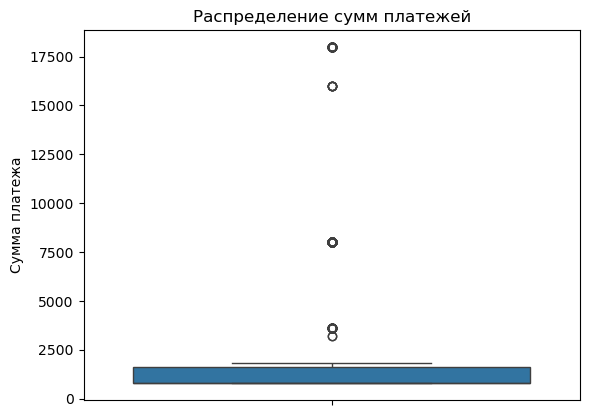

In [19]:
# Распределение платежей пользователей.
# Основная часть платежей находится в диапазоне до 2500 рублей. Имеются выбросы от которых стоит избавиться.
sns.boxplot(payments['sum_payment'])
plt.title('Распределение сумм платежей')
plt.ylabel('Сумма платежа')
plt.savefig('Распределение сумм платежей.png', dpi = 300, bbox_inches = 'tight', transparent = True)
plt.show()

In [20]:
# Расчёт границ  для выбросов в колонке age с помощью метода IQR (межквартильного размаха).
Q1 = np.percentile(payments['sum_payment'], 25)
Q3 = np.percentile(payments['sum_payment'], 75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print(lower_bound)
print(upper_bound)

-400.0
2800.0


In [21]:
# Удаление выбросов из таблицы.
payments = payments.loc[(payments['sum_payment'] > lower_bound) & (payments['sum_payment'] < upper_bound)].copy()
payments.head()

,id_user,training_type,sum_payment,date
0,1000,indiv,1800.0,2023-03-04
1,1000,indiv,1800.0,2023-03-21
2,1000,indiv,1800.0,2023-04-03
3,1000,indiv,1800.0,2023-04-12
4,1000,indiv,1800.0,2023-04-20


### Задача 2. Агрегация данных

In [22]:
# Создан новый столбец mon только с месяцем и годом.
payments['mon'] = payments['date'].dt.strftime('%Y-%m')
payments.head()

,id_user,training_type,sum_payment,date,mon
0,1000,indiv,1800.0,2023-03-04,2023-03
1,1000,indiv,1800.0,2023-03-21,2023-03
2,1000,indiv,1800.0,2023-04-03,2023-04
3,1000,indiv,1800.0,2023-04-12,2023-04
4,1000,indiv,1800.0,2023-04-20,2023-04


In [23]:
# Расчёт количества тренировок каждого типа и сумма оплаты по этим тренировкам по каждому месяцу и клиенту с помощью группировки и агрегации.
pivot_pay = pd.pivot_table(payments \
                           , values = 'sum_payment' \
                           , index = ['id_user', 'mon'] \
                           , columns =  'training_type' \
                           , aggfunc = ['count', 'sum'] \
                           , fill_value = 0).reset_index()
pivot_pay.head()

id_user      mon count         sum        
training_type                  group indiv group   indiv
0                1000  2023-03     0     2   0.0  3600.0
1                1000  2023-04     0     4   0.0  7200.0
2                1000  2023-05     0     4   0.0  6400.0
3                1000  2023-06     0     2   0.0  3600.0
4                1000  2023-07     0     4   0.0  7200.0

In [24]:
# Создано 2 новых столбца cnt_total и sum_total, с общим количеством тренировок и общей суммой оплаты за тренировки по каждому
# месяцу и клиенту.
pivot_pay.columns = ['id_user', 'mon', 'cnt_group', 'cnt_indiv', 'sum_group', 'sum_indiv']
pivot_pay['cnt_total'] = pivot_pay['cnt_group'] + pivot_pay['cnt_indiv']
pivot_pay['sum_total'] = pivot_pay['sum_group'] + pivot_pay['sum_indiv']
pivot_pay.head()

,id_user,mon,cnt_group,cnt_indiv,sum_group,sum_indiv,cnt_total,sum_total
0,1000,2023-03,0,2,0.0,3600.0,2,3600.0
1,1000,2023-04,0,4,0.0,7200.0,4,7200.0
2,1000,2023-05,0,4,0.0,6400.0,4,6400.0
3,1000,2023-06,0,2,0.0,3600.0,2,3600.0
4,1000,2023-07,0,4,0.0,7200.0,4,7200.0


### Задача 3. Анализ выручки и количества тренировок

In [25]:
# Расчёт для каждого месяца количества групповых тренировок, индивидуальных тренировок, тренировок всего, сумма оплаты
# по каждому типу тренировок и общая сумма оплаты.
payments_gr = pivot_pay.groupby('mon')[['cnt_group', 'cnt_indiv', 'cnt_total', 'sum_group', 'sum_indiv', 'sum_total']].sum().reset_index()
payments_gr

,mon,cnt_group,cnt_indiv,cnt_total,sum_group,sum_indiv,sum_total
0,2023-01,1787,856,2643,1437600.0,1540800.0,2978400.0
1,2023-02,1804,920,2724,1447200.0,1656000.0,3103200.0
2,2023-03,1789,872,2661,1439200.0,1569600.0,3008800.0
3,2023-04,1955,720,2675,1572800.0,1296000.0,2868800.0
4,2023-05,1541,1320,2861,1242400.0,2112000.0,3354400.0
5,2023-06,2315,680,2995,1864000.0,1224000.0,3088000.0
6,2023-07,2457,741,3198,1976800.0,1333800.0,3310600.0
7,2023-08,2474,728,3202,1988000.0,1310400.0,3298400.0
8,2023-09,2444,745,3189,1968000.0,1341000.0,3309000.0
9,2023-10,2504,724,3228,2015200.0,1303200.0,3318400.0


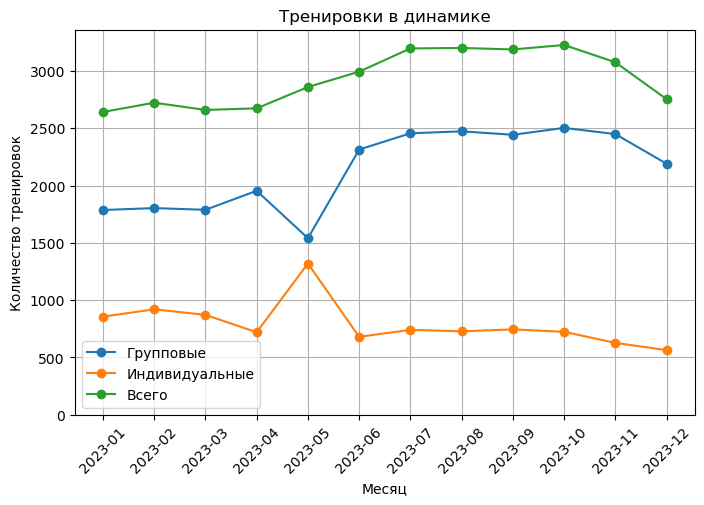

In [26]:
# Динамика тренировок по месяцам.
plt.figure(figsize=(8, 5))
plt.plot(payments_gr['mon'], payments_gr['cnt_group'], marker = 'o', label = 'Групповые')
plt.plot(payments_gr['mon'], payments_gr['cnt_indiv'], marker = 'o', label = 'Индивидуальные')
plt.plot(payments_gr['mon'], payments_gr['cnt_total'], marker = 'o', label = 'Всего')
plt.xlabel('Месяц')
plt.ylabel('Количество тренировок')
plt.title('Тренировки в динамике')
plt.legend()
plt.grid(True)
plt.ylim(bottom = 0)  # начинаем ось Y с нуля
plt.xticks(rotation = 45)  # поворот подписей на оси X
#plt.savefig('Тренировки в динамике.png', dpi = 300, bbox_inches = 'tight', transparent = True)
plt.show()

По всем тренировкам с января по апрель наблюдается стабильность в количестве тренировок и начиная с мая количество тренировок растёт.\
Затем с июля по октябрь количество общих тренировок стоит на уровне более 3000 тренировок в месяц, а начиная с ноября их количество идёт на спад.

В мае проводилась маркетинговая акция по снижению цены на индивидуальные тренировки. На графике видно, что одновременно с ростом количества\
индивидуальных тренировок, падает количество групповых тренировок в мае. Это говорит о том, что клиенты не стали увеличивать количество тренировок, а поменяли групповые занятия на индивидуальные тренировки на которые была скидка. 

Но в целом количество групповых тренировок с января по март остаётся стабильным, и с апреля по июль наблюдается рост количества тренировок за исключением мая, далее количество тренировок остаётся на уровне 2500 в месяц и с ноября их количество снижается.\
На протяжении всего периода количество групповых тренировок значительно выше индивидуальных.

В динамике количества индивидуальных тренировок на протяжении всего периода наблюдаеся постепенный спад за исключением отрезка с июля по сентябрь\
и мая.

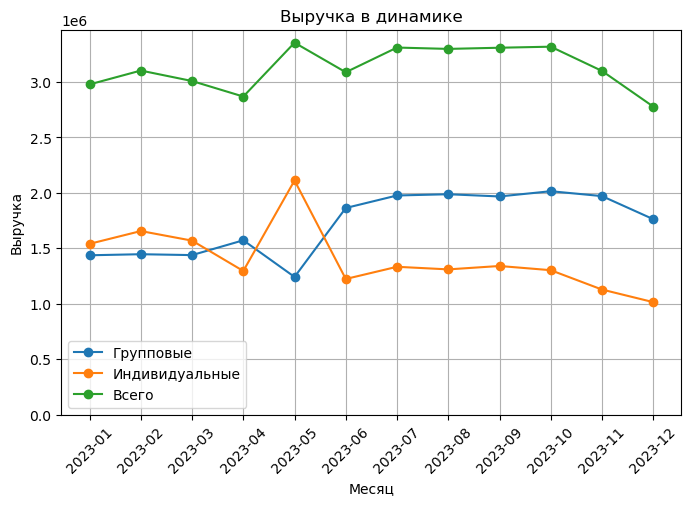

In [27]:
# Динамика выручки по месяцам.
plt.figure(figsize=(8, 5))
plt.plot(payments_gr['mon'], payments_gr['sum_group'], marker = 'o', label='Групповые')
plt.plot(payments_gr['mon'], payments_gr['sum_indiv'], marker = 'o', label='Индивидуальные')
plt.plot(payments_gr['mon'], payments_gr['sum_total'], marker = 'o', label='Всего')
plt.xlabel('Месяц')
plt.ylabel('Выручка')
plt.title('Выручка в динамике')
plt.legend()
plt.grid(True)
plt.ylim(bottom = 0)  # начинаем ось Y с нуля
plt.xticks(rotation=45)  # поворот подписей на оси X
#plt.savefig('Выручка в динамике.png', dpi = 300, bbox_inches = 'tight', transparent = True)
plt.show()

### Задача 4. Считаем LT и LTR

In [28]:
# Создан новый столбец min_mon - месяц начала занятий клиента и столбец max_mon - месяц конца занятий клиента.
pivot_pay['min_mon'] = pivot_pay.groupby('id_user')['mon'].transform('min')
pivot_pay['max_mon'] = pivot_pay.groupby('id_user')['mon'].transform('max')
pivot_pay.head()

,id_user,mon,cnt_group,cnt_indiv,sum_group,sum_indiv,cnt_total,sum_total,min_mon,max_mon
0,1000,2023-03,0,2,0.0,3600.0,2,3600.0,2023-03,2023-12
1,1000,2023-04,0,4,0.0,7200.0,4,7200.0,2023-03,2023-12
2,1000,2023-05,0,4,0.0,6400.0,4,6400.0,2023-03,2023-12
3,1000,2023-06,0,2,0.0,3600.0,2,3600.0,2023-03,2023-12
4,1000,2023-07,0,4,0.0,7200.0,4,7200.0,2023-03,2023-12


In [29]:
# Расчёт для каждого пользователя суммы оплат по всем месяцам тренировок, среднее и медиана по столбцу ltr.
pay_ltr = pivot_pay.groupby('id_user').agg(ltr = ('sum_total', 'sum')).reset_index()
print(round(pay_ltr['ltr'].mean(), 2))
print(round(pay_ltr['ltr'].median(), 2))
pay_ltr.head()

38716.41
30600.0


,id_user,ltr
0,1000,58600.0
1,1001,124800.0
2,1002,166000.0
3,1003,55800.0
4,1004,32000.0


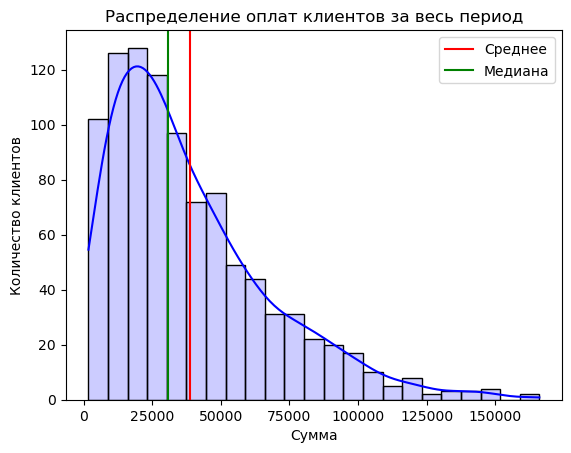

In [30]:
# Распределение оплат клиентов за весь период.
sns.histplot(pay_ltr['ltr'], kde = True, color='b', alpha = 0.2)
plt.xlabel('Сумма')
plt.ylabel('Количество клиентов')
plt.title('Распределение оплат клиентов за весь период')
plt.axvline(pay_ltr['ltr'].mean(), color='red', label = 'Среднее')
plt.axvline(pay_ltr['ltr'].median(), color='g', label = 'Медиана')
plt.legend()
plt.savefig('Распределение оплат клиентов за весь период.png', dpi=300, bbox_inches = 'tight', transparent = True)
plt.show()


In [31]:
# Исключён максимальный месяц потому, что данных после декабря нет и возможно некоторые клиенты продолжили занятия после декабря
# и если взять в расчёт этих клиентов, то ltr будет занижен. Оставим клиентов которые полностью завершили занятия.
pay_ltr_clean = pivot_pay.loc[pivot_pay['max_mon']!= '2023-12']
print(len(pivot_pay))
print(len(pay_ltr_clean))
pay_ltr_clean.head(2)

5293
2558


,id_user,mon,cnt_group,cnt_indiv,sum_group,sum_indiv,cnt_total,sum_total,min_mon,max_mon
31,1003,2023-01,0,6,0.0,10800.0,6,10800.0,2023-01,2023-09
32,1003,2023-02,0,2,0.0,3600.0,2,3600.0,2023-01,2023-09


In [32]:
# Расчёт для каждого пользователя суммы оплат по всем месяцам тренировок, среднего и медианы по столбцу ltr.
# После того как были исключены клиенты которые продолжают заниматься в декабре, в нашей выборке остались клиенты,
# которые начали заниматься позже тех клиентов, которых мы исключили и соответсвенно закончили заниматься раньше их.
clean_gr = pay_ltr_clean.groupby('id_user').agg(ltr = ('sum_total', 'sum')).reset_index()
print(round(clean_gr['ltr'].mean(), 2))
print(round(clean_gr['ltr'].median(), 2))
clean_gr.head(2)

32633.27
25600.0


,id_user,ltr
0,1003,55800.0
1,1004,32000.0


In [33]:
# В расчёт возьмём клиентов, которые начали заниматься в первые четыре месяца года.
clean_pay2 = pivot_pay.loc[pivot_pay['min_mon'].isin(['2023-01', '2023-02', '2023-03', '2023-04'])]
print(len(pivot_pay))
print(len(clean_pay2))
clean_pay2.head()

5293
4165


,id_user,mon,cnt_group,cnt_indiv,sum_group,sum_indiv,cnt_total,sum_total,min_mon,max_mon
0,1000,2023-03,0,2,0.0,3600.0,2,3600.0,2023-03,2023-12
1,1000,2023-04,0,4,0.0,7200.0,4,7200.0,2023-03,2023-12
2,1000,2023-05,0,4,0.0,6400.0,4,6400.0,2023-03,2023-12
3,1000,2023-06,0,2,0.0,3600.0,2,3600.0,2023-03,2023-12
4,1000,2023-07,0,4,0.0,7200.0,4,7200.0,2023-03,2023-12


In [34]:
# Расчёт для каждого пользователя суммы оплат по всем месяцам тренировок. Расчёт LTR по столбцу ltr с помощью median.
clean_gr2 = clean_pay2.groupby('id_user').agg(ltr = ('sum_total', 'sum')).reset_index()
print(round(clean_gr2['ltr'].mean(), 2))
print(round(clean_gr2['ltr'].median(), 2))
clean_gr2.head()

43922.52
36000.0


,id_user,ltr
0,1000,58600.0
1,1001,124800.0
2,1002,166000.0
3,1003,55800.0
4,1004,32000.0


In [35]:
print(f'В среднем один клиент приносит за всё время тренировок {round(clean_gr2['ltr'].median(), 2)} рублей.')

В среднем один клиент приносит за всё время тренировок 36000.0 рублей.


In [36]:
# Расчёт количества месяцев для каждого клиента, которые он занимался. Расчёт LT по столбцу nmon с помощью mean.
p_group = clean_pay2.groupby('id_user').agg(nmon = ('id_user', 'count')).reset_index()
print(p_group['nmon'].mean())
print(p_group['nmon'].median())
p_group.head()

6.253753753753754
7.0


,id_user,nmon
0,1000,9
1,1001,11
2,1002,11
3,1003,6
4,1004,9


In [37]:
print(f'Среднее количество месяцев посещений фитнес-клуба: {round(p_group['nmon'].mean(), 2)} месяцев.')

Среднее количество месяцев посещений фитнес-клуба: 6.25 месяцев.


### Задача 5. Анализ маркетинговой акции

In [38]:
# Количество индивидуальных тренировок в апреле. 
cnt_indiv_apr = payments_gr.loc[payments_gr['mon'] == '2023-04', 'cnt_indiv'].iloc[0]
print(cnt_indiv_apr)

# Количество групповых тренировок в апреле.
cnt_group_apr = payments_gr.loc[payments_gr['mon'] == '2023-04', 'cnt_group'].iloc[0]
print(cnt_group_apr)

# Количество индивидуальных тренировок в мае.
cnt_indiv_may = payments_gr.loc[payments_gr['mon'] == '2023-05', 'cnt_indiv'].iloc[0]
print(cnt_indiv_may)

# Количество групповых тренировок в мае.
cnt_group_may = payments_gr.loc[payments_gr['mon'] == '2023-05', 'cnt_group'].iloc[0]
print(cnt_group_may)

# Количество индивидуальных тренировок в июне.
cnt_indiv_june = payments_gr.loc[payments_gr['mon'] == '2023-06', 'cnt_indiv'].iloc[0]
print(cnt_indiv_june)

# Количество групповых тренировок в июне.
cnt_group_june = payments_gr.loc[payments_gr['mon'] == '2023-06', 'cnt_group'].iloc[0]
print(cnt_group_june)

720
1955
1320
1541
680
2315


In [39]:
# Факт.выручка за май
rev_fact_may = payments_gr.loc[payments_gr['mon'] == '2023-05', 'sum_total'].item()
print(rev_fact_may)

3354400.0


In [40]:
# Гипотетическая выручка за май
rev_hyp_may = (cnt_indiv_apr + cnt_indiv_june) * 0.5 * 1800 + \
               (cnt_group_apr + cnt_group_june) * 0.5 * 800
print(rev_hyp_may)

2968000.0


In [41]:
print(f'Прирост выручки от проведения маркетинговой акции составил: {rev_fact_may - rev_hyp_may} руб.')

Прирост выручки от проведения маркетинговой акции составил: 386400.0 руб.


In [42]:
# Факт.прибыль за май
prof_fact_may = cnt_indiv_may * (1600 - 800) + cnt_group_may * (800 - 200)
print(prof_fact_may)

1980600


In [43]:
# Гипотетическая прибыль за май
prof_hyp_may = (cnt_indiv_apr + cnt_indiv_june) * 0.5 * (1800 - 800) + \
               (cnt_group_apr + cnt_group_june) * 0.5 * (800 - 200)
print(prof_hyp_may)

1981000.0


In [44]:
print(f'Прирост прибыли от проведения маркетинговой акции в мае составил: {prof_fact_may - prof_hyp_may} руб.')

Прирост прибыли от проведения маркетинговой акции в мае составил: -400.0 руб.


##### Индивидуальная тренировка - 1800 рублей.
##### Групповая тренировка - 800 рублей.
##### Индивидуальная тренировка (маркетинговая акция) - 1600 рублей.

После проведения маркетинговой акции в мае, прирост прибыли составил -400.0 рублей. Это произошло потому, что увеличилось количество индивидуальных тренировок, стоимость которых дороже, и вследствии чего произошёл прирост выручки. Но этот прирост выручки не смог покрыть прирост затрат на индивидуальные тренировки (оплата тренеру за тренировку 800 рублей). Так же клиенты не стали увеличивать общее количество тренировок, а прирост по индивидуальным тренировкам произошёл из - за того, что люди заменили групповые тренировки индивидуальными.